# ML Assignment 2 – Bank Marketing Dataset

In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

import joblib, os, warnings
warnings.filterwarnings("ignore")


In [2]:

DATASET_PATH = "bank-full.csv"
df = pd.read_csv(DATASET_PATH, sep=";")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:

print("Shape:", df.shape)
print("Target distribution:\n", df['y'].value_counts())
print("Missing values:", df.isnull().sum().sum())


Shape: (45211, 17)
Target distribution:
 y
no     39922
yes     5289
Name: count, dtype: int64
Missing values: 0


In [4]:

df['y'] = df['y'].map({'yes': 1, 'no': 0})


In [7]:

categorical_cols = df.select_dtypes(include='object').columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


In [8]:

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


In [9]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }


In [11]:

results = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        results[name] = evaluate_model(model, X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        results[name] = evaluate_model(model, X_test, y_test)


In [12]:

results_df = pd.DataFrame(results).T
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.891002,0.870741,0.591463,0.220121,0.320838,0.314978
Decision Tree,0.874104,0.704609,0.463379,0.483359,0.473158,0.401820
KNN,0.891799,0.813054,0.566622,0.318457,0.407748,0.371141
Naive Bayes,0.840927,0.813212,0.353988,0.436460,0.390921,0.302763
Random Forest,0.906750,0.923778,0.659905,0.418306,0.512037,0.478078
XGBoost,0.905866,0.927747,0.631902,0.467474,0.537391,0.493144


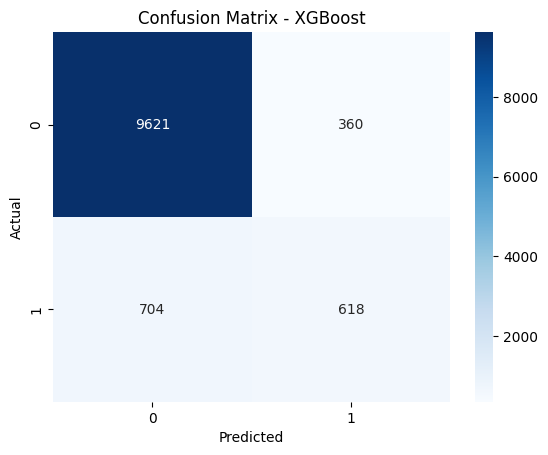

In [13]:

best_model = models["XGBoost"]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [14]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.96      0.95      9981
           1       0.63      0.47      0.54      1322

    accuracy                           0.91     11303
   macro avg       0.78      0.72      0.74     11303
weighted avg       0.90      0.91      0.90     11303



In [16]:

os.makedirs("model", exist_ok=True)

joblib.dump(models["Logistic Regression"], "model/logistic.pkl")
joblib.dump(models["Decision Tree"], "model/decision_tree.pkl")
joblib.dump(models["KNN"], "model/knn.pkl")
joblib.dump(models["Naive Bayes"], "model/naive_bayes.pkl")
joblib.dump(models["Random Forest"], "model/random_forest.pkl")
joblib.dump(best_model, "model/xgboost.pkl")
joblib.dump(scaler, "model/scaler.pkl")


['model/scaler.pkl']